In [2]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 24}

plt.rc( 'font',**font);

In [3]:
merg = pd.read_hdf(r'D:\obstacle_avoidance\recordings\072523\G8CKLN\oa\processed_G8CKLN_072523_oa.h5')

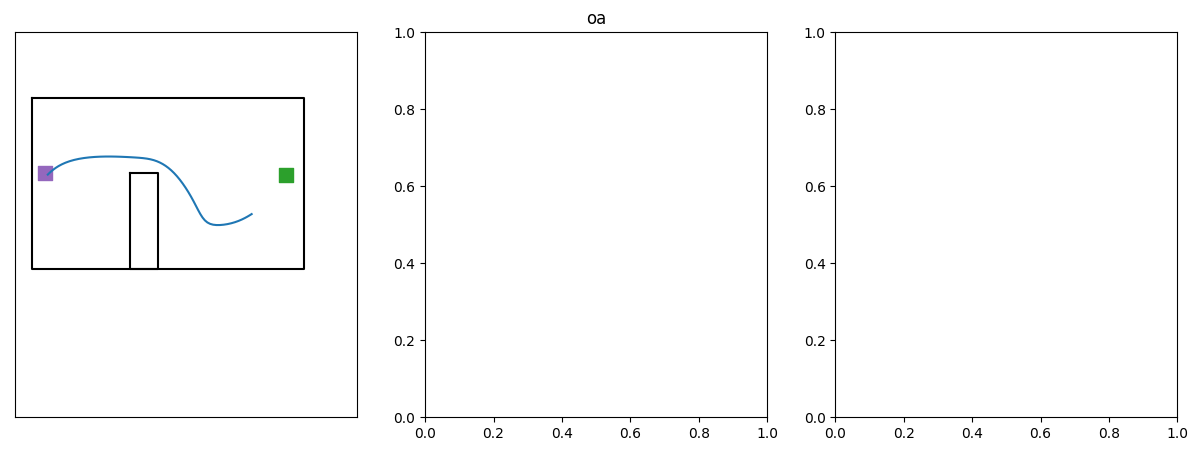

In [36]:
test = merg.sample(1)
#test = test[test.num_turn >= 3].sample(50)


for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,3,figsize=(15,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



   
    ax[1].set_title(str(row.task) )
 


    

  
    ax[0].plot(row.ts_nose_x_cm,row.ts_nose_y_cm)
    

In [40]:
import cv2
import os

def extract_frames(video_path, frame_indices, output_dir):  
    """
    Extracts specified frames from a video and saves them as images.
    
    Parameters:
    - video_path (str): Path to the input video file.
    - frame_indices (list of int): List of frame indices to extract.
    - output_dir (str): Directory where the extracted frames will be saved.
    
    Returns:
    - None
    """
    # Check if the output directory exists, create if it doesn't
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print("Error: Could not open video file.")
        return
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = [i for i in frame_indices if i < total_frames]  # Filter valid frame indices
    
    # Read each frame
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()
        
        if success:
            frame_filename = os.path.join(output_dir, f"frame_{idx}.png")
            cv2.imwrite(frame_filename, frame)
            print(f"Saved frame {idx} to {frame_filename}")
        else:
            print(f"Warning: Could not extract frame {idx}.")
    
    # Release the video capture object
    cap.release()
    print("Frame extraction completed.")

# Example usage
# video_path = "path/to/your/video.mp4"
# frame_indices = [10, 50, 100]  # Specify the frame indices to extract
# output_dir = "output_frames"
# extract_frames(video_path, frame_indices, output_dir)



In [55]:

extract_frames(r"D:\obstacle_avoidance\recordings\072523\G8CKLN\oa\072523_G8CKLN_whiteblack_Rig2_oa_top1.avi", trial_df.trial_vidframes.tolist()[0].tolist()[0], r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames")

Saved frame 4532 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4532.png
Saved frame 4533 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4533.png
Saved frame 4534 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4534.png
Saved frame 4535 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4535.png
Saved frame 4536 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4536.png
Saved frame 4537 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4537.png
Saved frame 4538 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4538.png
Saved frame 4539 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4539.png
Saved frame 4540 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frame

In [56]:
light_trial_permin = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_trial_permin.h5")

In [58]:
d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one

array(['oa', 'training', 'oa1'], dtype=object)

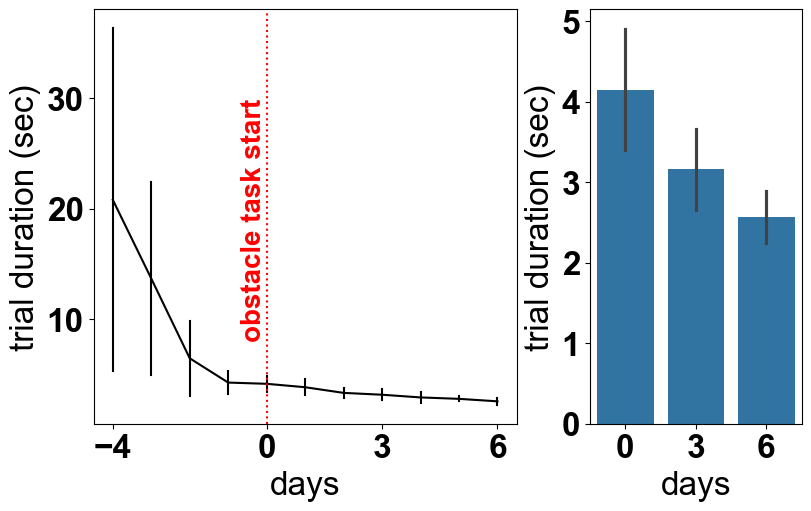

In [61]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('days')
ax1.set_ylabel('trial duration (sec)')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('days')
ax2.set_ylabel('trial duration (sec)')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trial_time' ,errorbar='sd',err_style='bars',color = 'black')

bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
ax1.axvline(0, color='r', ls=':')
ax1.text(0, ax1.get_ylim()[1]/2,'obstacle task start', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax1.set_xticks([-4,0,3,6])
   
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trial_time',errorbar = 'sd')
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_time.pdf',dpi = 300)

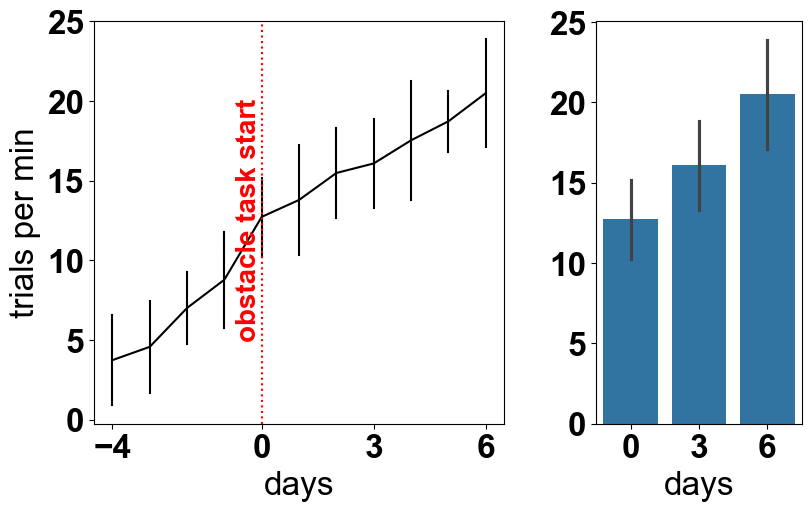

In [62]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('days')
ax1.set_ylabel('trials per min')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('days')
ax2.set_ylabel(' ')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trialpermin' ,errorbar='sd',err_style='bars',color = 'black')
ax1.set_xticks([-4,0,3,6])
   
bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trialpermin',errorbar = 'sd')
ax1.axvline(0, color='r', ls=':')
ax1.text(0, ax1.get_ylim()[1]/2,'obstacle task start', color='r', ha='right', va='center', rotation=90,fontsize=20)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_permin.pdf',dpi = 300)